
# 🚀 Day 31: Dimensionality Reduction, SVD, PCA & KMeans
## Theory Heavy Notebook + Practical ML Intuition

---

# 🎯 Learning Goals

In this notebook we will learn:

- What is Dimensionality Reduction
- Curse of Dimensionality
- Singular Value Decomposition (SVD)
- Principal Component Analysis (PCA)
- Relationship between SVD and PCA
- PCA vs KMeans
- Practical BFSI use cases
- Advantages & Limitations
- Interview Questions
- Hands-on Python Examples

---



# ⚠️ Curse of Dimensionality

Modern ML datasets can contain:

- Hundreds of features
- Thousands of dimensions
- Sparse vectors
- Redundant information

As dimensions increase:

❌ Distance calculations become unstable  
❌ Models become slower  
❌ Overfitting increases  
❌ Storage cost increases  

This problem is called:

# Curse of Dimensionality



# 📉 What is Dimensionality Reduction?

Dimensionality Reduction means:

> Reducing the number of features while preserving important information.

Example:

| Original | Reduced |
|---|---|
| 1000 features | 50 features |
| High-dimensional image | Compact latent vector |
| Large sparse vectors | Dense meaningful representation |

---

# 🎯 Benefits

✅ Faster Training  
✅ Less Memory  
✅ Better Visualization  
✅ Noise Reduction  
✅ Reduced Overfitting



# 🔍 Singular Value Decomposition (SVD)

SVD is one of the most important matrix decomposition techniques in Machine Learning.

It decomposes a matrix into:




\[
A = U \Sigma V^T
\]

Where:

| Matrix | Meaning |
|---|---|
| U | Left Singular Vectors |
| Σ | Singular Values |
| Vᵀ | Right Singular Vectors |



# 🧠 Intuition Behind SVD

SVD breaks complex data into:

- Important hidden patterns
- Latent relationships
- Compact mathematical representations

It helps us:

✅ Compress information  
✅ Discover hidden structure  
✅ Reduce dimensions  
✅ Build recommender systems

---

# 🌍 Real Use Cases

| Domain | Usage |
|---|---|
| Netflix | Recommendation Engine |
| NLP | Latent Semantic Analysis |
| Search Engines | Semantic Retrieval |
| Images | Compression |
| AI Systems | Embedding Compression |


In [1]:

import numpy as np

A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

U, S, VT = np.linalg.svd(A)

print("U Matrix:\n", U)
print("\nSingular Values:\n", S)
print("\nVT Matrix:\n", VT)


U Matrix:
 [[-0.2298477   0.88346102  0.40824829]
 [-0.52474482  0.24078249 -0.81649658]
 [-0.81964194 -0.40189603  0.40824829]]

Singular Values:
 [9.52551809 0.51430058]

VT Matrix:
 [[-0.61962948 -0.78489445]
 [-0.78489445  0.61962948]]



# 🎯 Principal Component Analysis (PCA)

PCA is one of the most popular dimensionality reduction algorithms.

PCA transforms data into:

> New orthogonal axes called Principal Components.

These components capture:

✅ Maximum variance  
✅ Important information  
✅ Reduced redundancy



# 📌 Important PCA Concepts

## 1. Variance

Higher variance = More information.

---

## 2. Covariance Matrix

Shows relationships between variables.

---

## 3. Eigenvectors

Direction of maximum variance.

---

## 4. Eigenvalues

Amount of variance captured.



# 🔄 PCA Workflow

## Step 1: Standardize Data

PCA is scale sensitive.

---

## Step 2: Compute Covariance Matrix

Understand feature relationships.

---

## Step 3: Compute Eigenvectors & Eigenvalues

Find important directions.

---

## Step 4: Keep Top Components

Reduce dimensions while preserving information.



# 🔗 How SVD is Related to PCA

This is a very important interview topic.

PCA can actually be implemented using SVD.

If:

X = UΣVᵀ

Then:

- V contains principal component directions
- Singular values represent component importance
- PCA uses these directions for dimensionality reduction

---

# 🎯 Key Idea

PCA = Goal  
SVD = Mathematical Engine

Modern ML libraries often use SVD internally to compute PCA efficiently.


In [2]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load dataset
X = load_iris().data

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)


Original Shape: (150, 4)
Reduced Shape: (150, 2)



# 📊 Explained Variance Ratio

This metric tells us:

> How much information each principal component preserves.

Example:

| Component | Variance |
|---|---|
| PC1 | 72% |
| PC2 | 18% |

This means first two components preserve most information.


In [3]:

print(pca.explained_variance_ratio_)


[0.72962445 0.22850762]


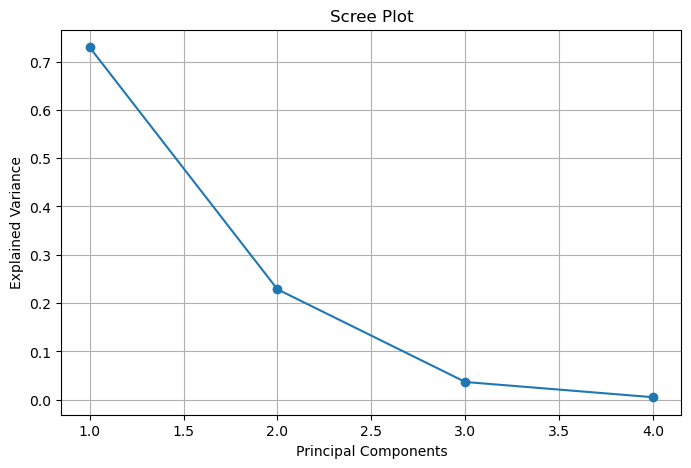

In [4]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_)+1),
    pca_full.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid(True)

plt.show()



# ⚔️ PCA vs KMeans

| PCA | KMeans |
|---|---|
| Dimensionality Reduction | Clustering |
| Reduces Features | Groups Data |
| Finds Variance Directions | Finds Centroids |
| Compression Technique | Segmentation Technique |

---

# 🎯 Relationship

PCA is often applied BEFORE KMeans because:

✅ Removes noise  
✅ Improves clustering  
✅ Reduces computation  
✅ Better cluster separation


In [5]:

from sklearn.cluster import KMeans

# PCA Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_pca)

print("Cluster Labels:\n")
print(kmeans.labels_)


Cluster Labels:

[1 2 2 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 1 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



# 🌍 Practical Applications

## 1. BFSI Fraud Detection

Banks may have:

- Hundreds of transaction features
- Highly correlated variables

PCA helps:

✅ Reduce noise  
✅ Compress features  
✅ Speed up anomaly detection

---

## 2. NLP

SVD is heavily used in:

- Semantic search
- Topic modeling
- Recommendation systems

---

## 3. Image Compression

Reduce image size while preserving quality.

---

## 4. Face Recognition

PCA creates compact facial representations called Eigenfaces.



# ✅ Advantages of PCA

| Advantage | Benefit |
|---|---|
| Faster Training | Fewer features |
| Less Memory | Compressed data |
| Better Visualization | 2D/3D plotting |
| Removes Noise | Better generalization |
| Reduces Overfitting | Simpler models |



# ❌ Limitations of PCA

| Limitation | Explanation |
|---|---|
| Linear Method | Cannot capture nonlinear patterns |
| Hard to Interpret | Components are abstract |
| Information Loss | Some variance removed |
| Sensitive to Scaling | Requires standardization |
| Not Ideal for Categorical Data | Mostly numeric features |



# 🧠 Interview Questions

## Q1. Why standardization before PCA?

Because PCA is variance-based.

---

## Q2. Is PCA supervised?

No. PCA is unsupervised.

---

## Q3. Why use PCA before KMeans?

Because clustering struggles in high-dimensional spaces.

---

## Q4. What is difference between PCA and SVD?

PCA is dimensionality reduction.

SVD is matrix factorization used to compute PCA efficiently.



# 🏁 Final Mental Model

## Think of PCA like:

> Compressing a large movie into a smaller file while preserving important scenes.

---

## Think of SVD like:

> Breaking a massive matrix into hidden building blocks.

Together they help AI systems:

✅ Learn faster  
✅ Reduce memory  
✅ Handle massive datasets  
✅ Improve scalability

---

# ✅ End of Day 31
